In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data.csv", encoding="cp1252", low_memory=False)
print(df.head())

  stn_code       sampling_date           state   location agency  \
0      150  February - M021990  Andhra Pradesh  Hyderabad    NaN   
1      151  February - M021990  Andhra Pradesh  Hyderabad    NaN   
2      152  February - M021990  Andhra Pradesh  Hyderabad    NaN   
3      150     March - M031990  Andhra Pradesh  Hyderabad    NaN   
4      151     March - M031990  Andhra Pradesh  Hyderabad    NaN   

                                 type  so2   no2  rspm  spm  \
0  Residential, Rural and other Areas  4.8  17.4   NaN  NaN   
1                     Industrial Area  3.1   7.0   NaN  NaN   
2  Residential, Rural and other Areas  6.2  28.5   NaN  NaN   
3  Residential, Rural and other Areas  6.3  14.7   NaN  NaN   
4                     Industrial Area  4.7   7.5   NaN  NaN   

  location_monitoring_station  pm2_5        date  
0                         NaN    NaN  1990-02-01  
1                         NaN    NaN  1990-02-01  
2                         NaN    NaN  1990-02-01  
3       

In [3]:
delhi = df[df["state"] == "Delhi"]
print(f"Delhi rows: {len(delhi)}")

Delhi rows: 8551


In [4]:
def compute_skewness(data):
    mean_val = np.mean(data)
    std_val  = np.std(data)

    standardized = (data - mean_val) / std_val
    skewness = np.mean(standardized ** 3)

    return skewness

    

In [5]:
def compute_kurtosis(data):
    mean_val = np.mean(data)
    std_val  = np.std(data)

    standardized = (data - mean_val) / std_val
    kurtosis = np.mean(standardized ** 4) - 3
    
    return kurtosis



In [6]:
pollutant_cols = ["pm2_5", "rspm", "no2", "so2"]

for col in pollutant_cols:
    data = delhi[col].dropna().values
    skew = compute_skewness(data)
    kurt = compute_kurtosis(data)
    print(f"{col}: skewness={skew:.2f}, kurtosis={kurt:.2f}")


pm2_5: skewness=1.31, kurtosis=2.71
rspm: skewness=1.17, kurtosis=1.63
no2: skewness=1.60, kurtosis=3.28
so2: skewness=3.46, kurtosis=26.01


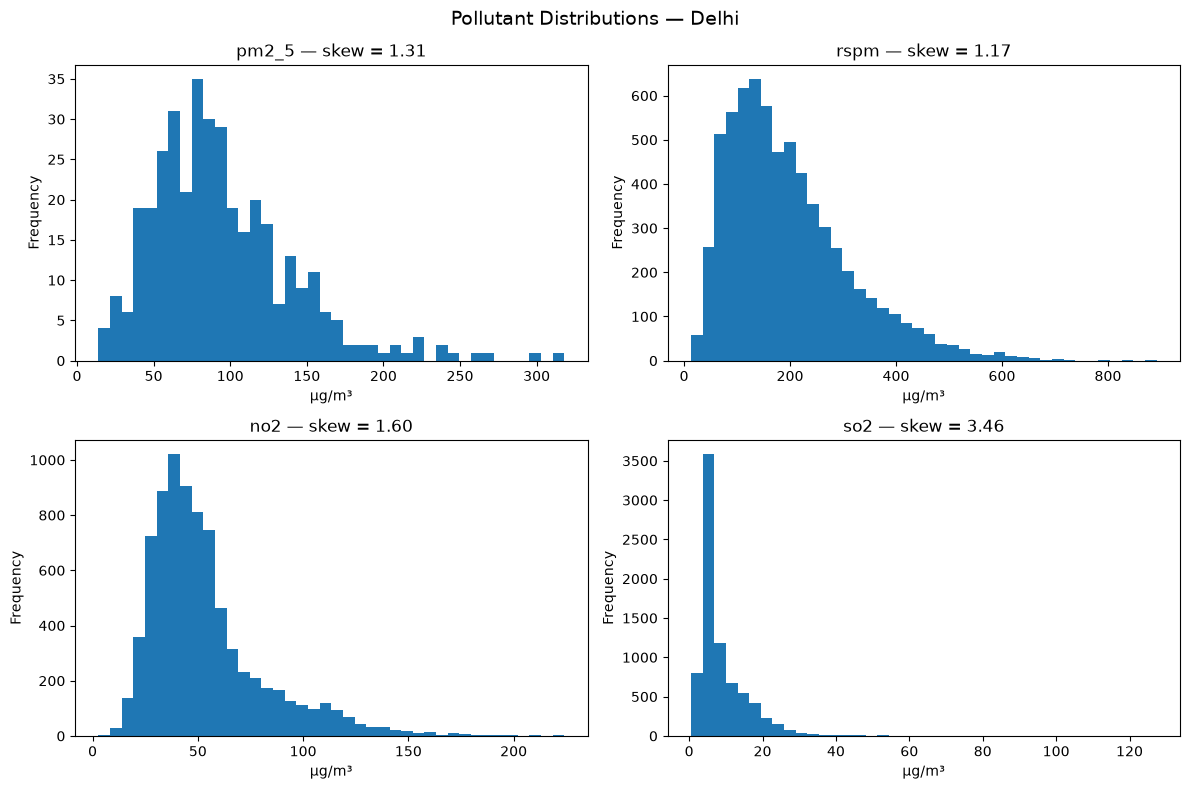

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

pollutant_cols = ["pm2_5", "rspm", "no2", "so2"]

for i, col in enumerate(pollutant_cols):
    data = delhi[col].dropna().values
    skew = compute_skewness(data)
    
    axes[i].hist(data, bins=40)
    axes[i].set_title(f"{col} — skew = {skew:.2f}")
    axes[i].set_xlabel("µg/m³")
    axes[i].set_ylabel("Frequency")

plt.suptitle("Pollutant Distributions — Delhi", fontsize=14)
plt.tight_layout()
plt.savefig("distribution_shapes.png", dpi=150)
plt.show()
